In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.pipeline import Pipeline
 
import umap

In [2]:
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "sans-serif",
})
 
RANDOM_STATE = 42

Load Data

In [ ]:
df = pd.read_csv("../data/BankChurners.csv")
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [4]:
# The dataset has two "Naive Bayes" columns at the end — drop them
# (they are outputs from a model the dataset creator ran, not features)
df = df.loc[:, ~df.columns.str.contains("Naive_Bayes")]

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (10127, 21)
Columns: ['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


Exploratory Data Analysis ( EDA )

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [6]:
df.isnull().sum()

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [7]:
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Duplicate rows: 0


In [8]:
print("\nAttrition breakdown (churn label):")
print(df["Attrition_Flag"].value_counts())


Attrition breakdown (churn label):
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64


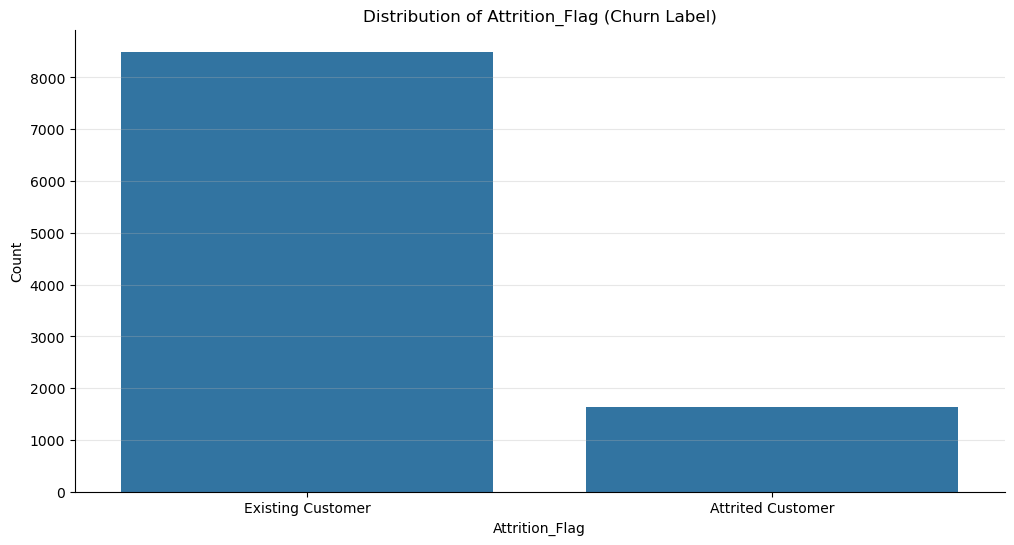

In [9]:
sns.countplot(x="Attrition_Flag", data=df)
plt.title("Distribution of Attrition_Flag (Churn Label)")
plt.xlabel("Attrition_Flag")
plt.ylabel("Count")
plt.show()

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.0,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


Distribution Plots

In [11]:
NUMERIC_COLS = [
    "Customer_Age", "Months_on_book", "Total_Relationship_Count",
    "Months_Inactive_12_mon", "Credit_Limit", "Total_Revolving_Bal",
    "Avg_Utilization_Ratio", "Total_Trans_Amt", "Total_Trans_Ct",
    "Total_Ct_Chng_Q4_Q1"
]

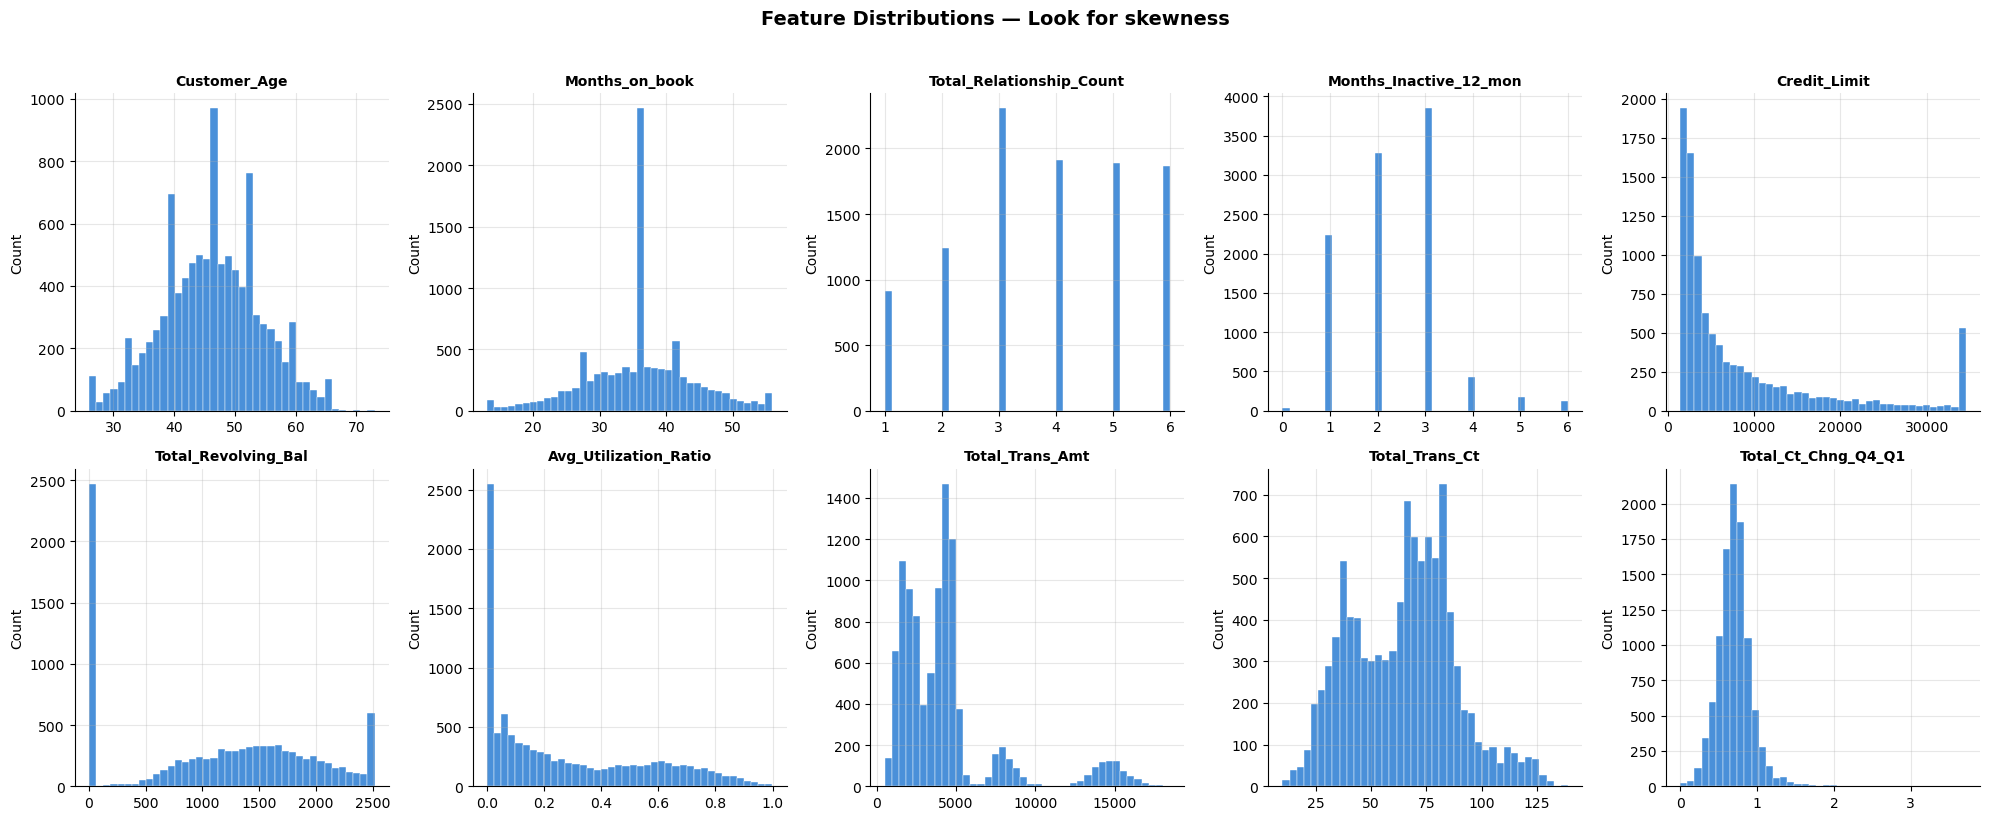

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
 
for i, col in enumerate(NUMERIC_COLS):
    axes[i].hist(df[col], bins=40, color="#4A90D9", edgecolor="white", linewidth=0.3)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
 
plt.suptitle("Feature Distributions — Look for skewness", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../plots/01_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Credit_Limit and Total_Trans_Amt are right-skewed.

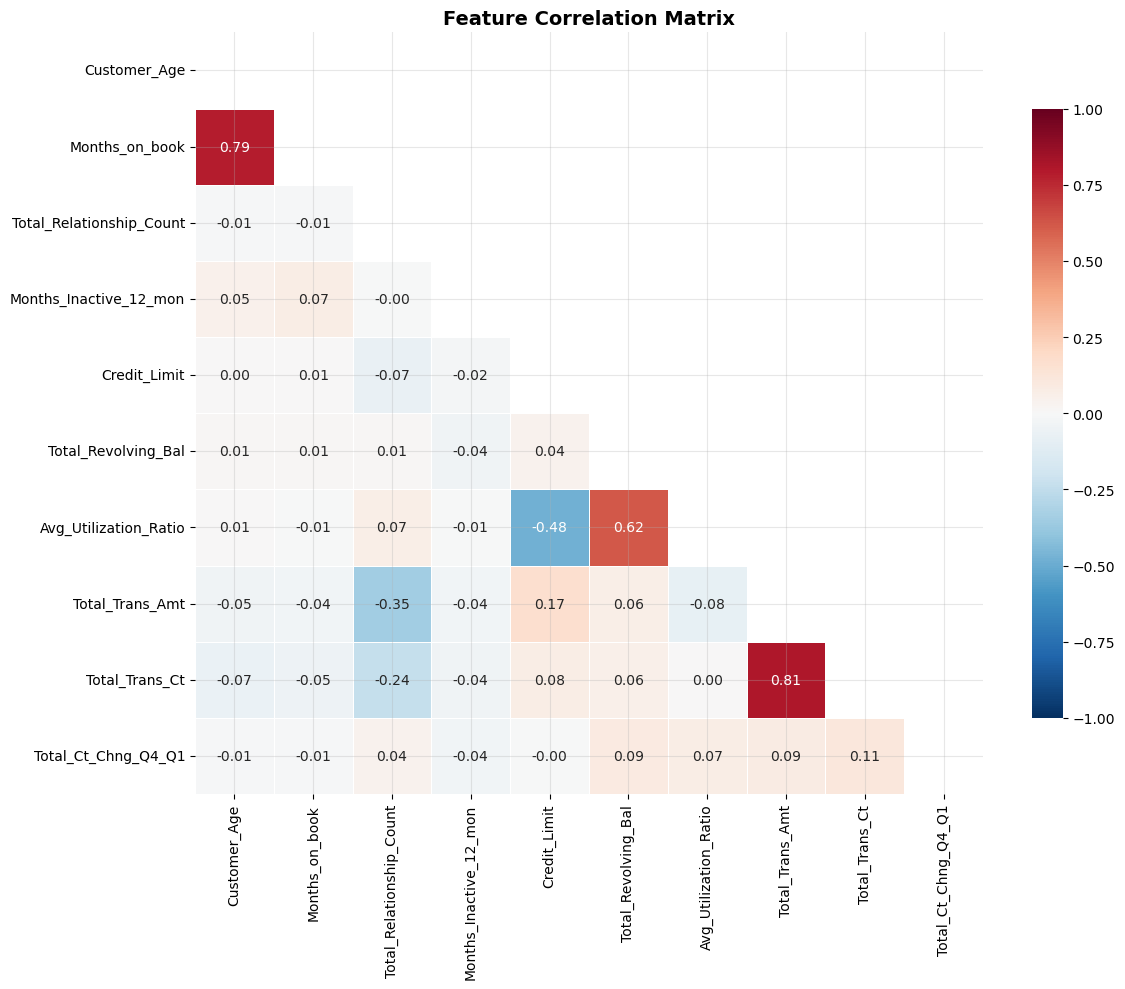

In [ ]:
corr = df[NUMERIC_COLS].corr()
 
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/02_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

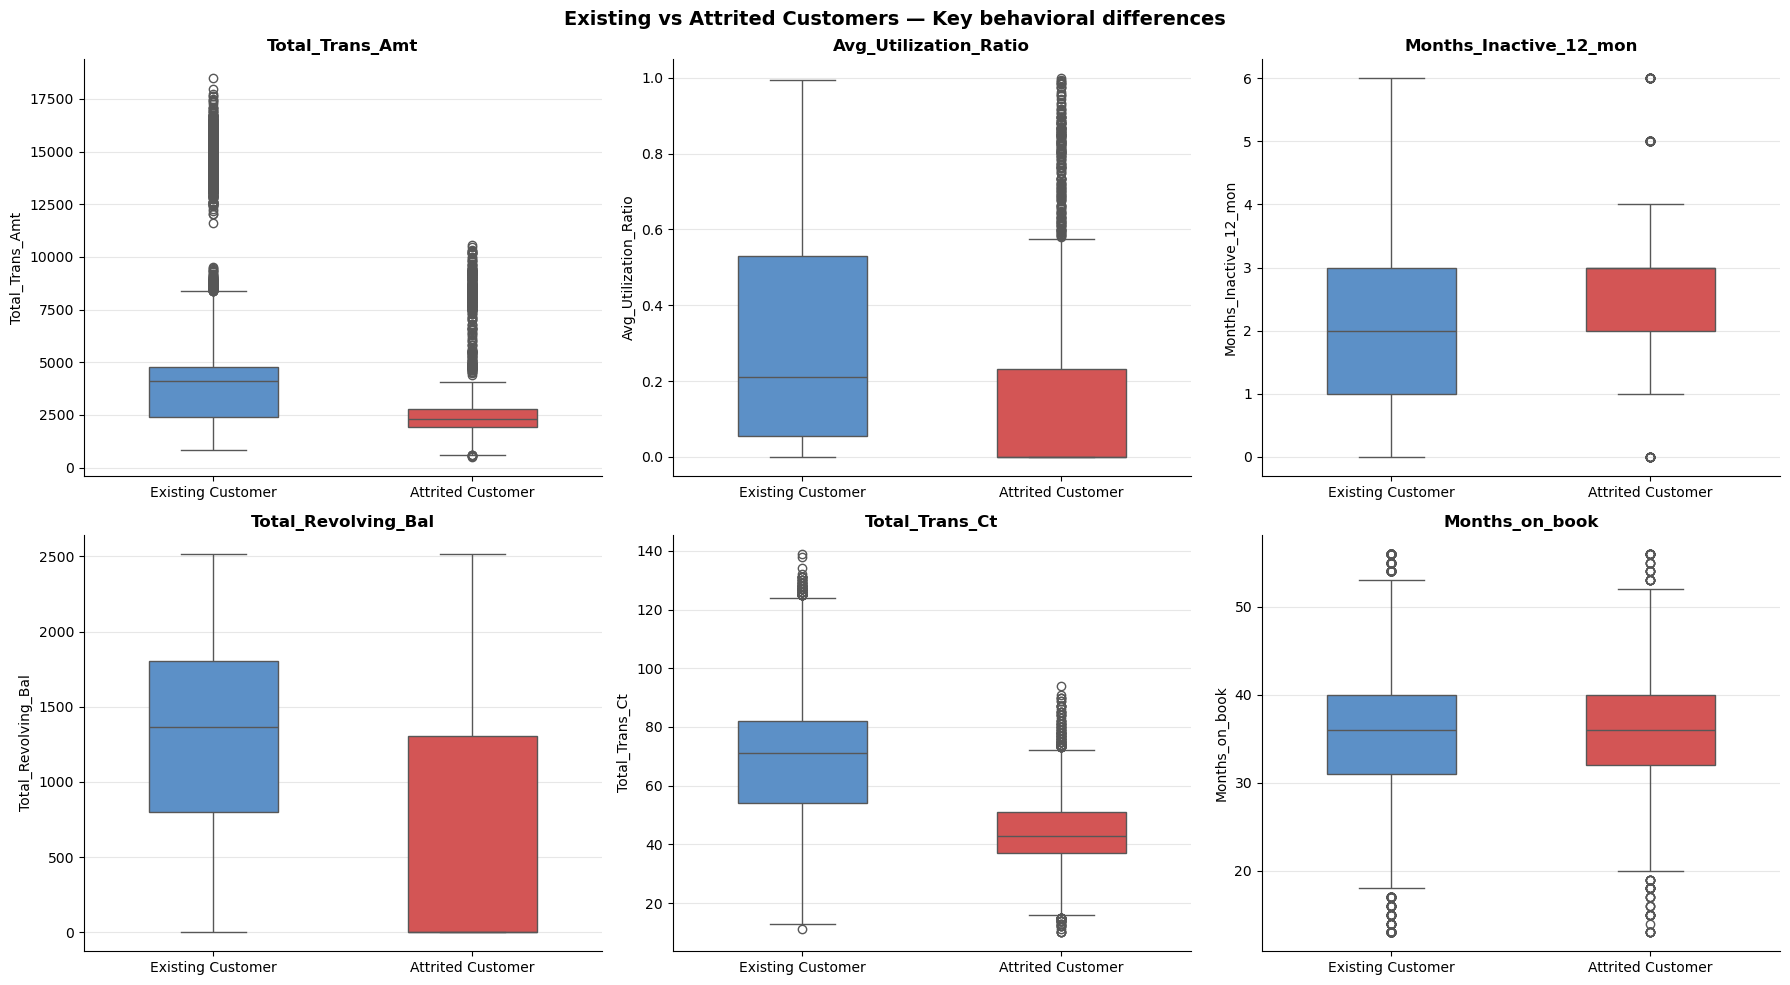

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
 
KEY_FEATURES = [
    "Total_Trans_Amt", "Avg_Utilization_Ratio",
    "Months_Inactive_12_mon", "Total_Revolving_Bal",
    "Total_Trans_Ct", "Months_on_book"
]
PALETTE = {"Existing Customer": "#4A90D9", "Attrited Customer": "#E84040"}
 
for i, col in enumerate(KEY_FEATURES):
    sns.boxplot(
        data=df, x="Attrition_Flag", y=col,
        palette=PALETTE, ax=axes[i], width=0.5
    )
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel("")
 
plt.suptitle("Existing vs Attrited Customers — Key behavioral differences", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/03_churn_vs_features.png", dpi=150, bbox_inches="tight")
plt.show()

Feature Selection & Preprocessing

In [16]:
CLUSTER_FEATURES = [
    "Customer_Age",
    "Months_on_book",            # Loyalty signal — how long they've been a customer
    "Total_Relationship_Count",  # How many products they hold
    "Months_Inactive_12_mon",    # Activity signal — months with no transaction
    "Credit_Limit",              # Bank's trust level in this customer
    "Total_Revolving_Bal",       # How much credit card debt they carry
    "Avg_Utilization_Ratio",     # Risk signal — how maxed-out they are (0 to 1)
    "Total_Trans_Amt",           # Spending signal — total money transacted
    "Total_Trans_Ct",            # Spending frequency
    "Total_Ct_Chng_Q4_Q1"        # Trend — is their activity growing or shrinking?
]

In [17]:
df_original = df.copy()
X = df[CLUSTER_FEATURES].copy()
 
print(f"Feature matrix shape: {X.shape}")
print(f"Any nulls: {X.isnull().any().any()}")

Feature matrix shape: (10127, 10)
Any nulls: False


In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


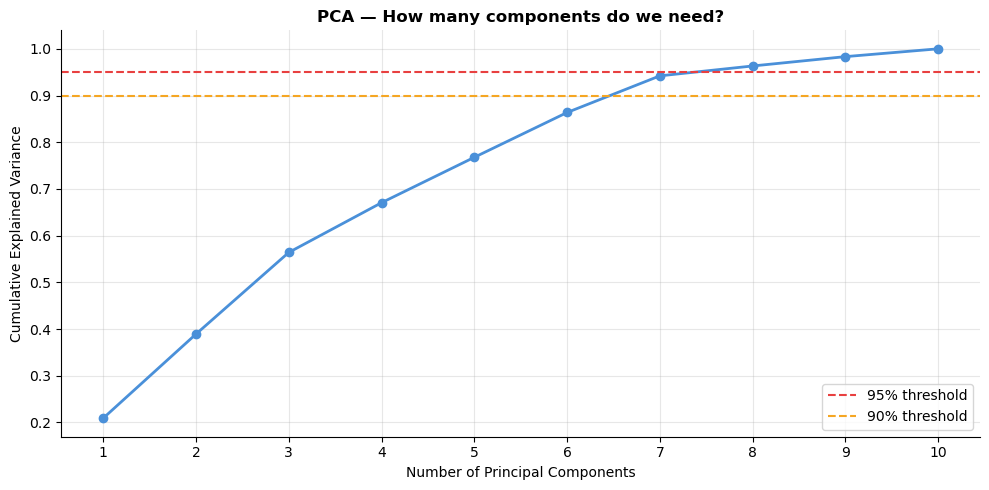

In [ ]:
# Cumulative explained variance plot
explained_var = np.cumsum(pca_full.explained_variance_ratio_)
 
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_var) + 1), explained_var, "o-", color="#4A90D9", linewidth=2)
plt.axhline(0.95, color="#E84040", linestyle="--", label="95% threshold")
plt.axhline(0.90, color="#F5A623", linestyle="--", label="90% threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — How many components do we need?", fontweight="bold")
plt.legend()
plt.xticks(range(1, 11))
plt.tight_layout()
plt.savefig("../plots/04_pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# Keep components explaining 95% of variance
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"\nComponents needed for 95% variance: {pca.n_components_}")
print(f"PCA output shape: {X_pca.shape}")


Components needed for 95% variance: 8
PCA output shape: (10127, 8)


In [22]:
K_RANGE = range(2, 11)
inertias = []
silhouettes = []
 
print("Running K-Means for k = 2 to 10...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=3000, random_state=RANDOM_STATE))
    print(f"  k={k}: inertia={km.inertia_:.0f}, silhouette={silhouettes[-1]:.4f}")
 

Running K-Means for k = 2 to 10...
  k=2: inertia=87592, silhouette=0.1436
  k=3: inertia=75295, silhouette=0.1637
  k=4: inertia=68712, silhouette=0.1426
  k=5: inertia=63441, silhouette=0.1559
  k=6: inertia=60239, silhouette=0.1420
  k=7: inertia=57264, silhouette=0.1454
  k=8: inertia=54727, silhouette=0.1306
  k=9: inertia=52679, silhouette=0.1352
  k=10: inertia=50809, silhouette=0.1343


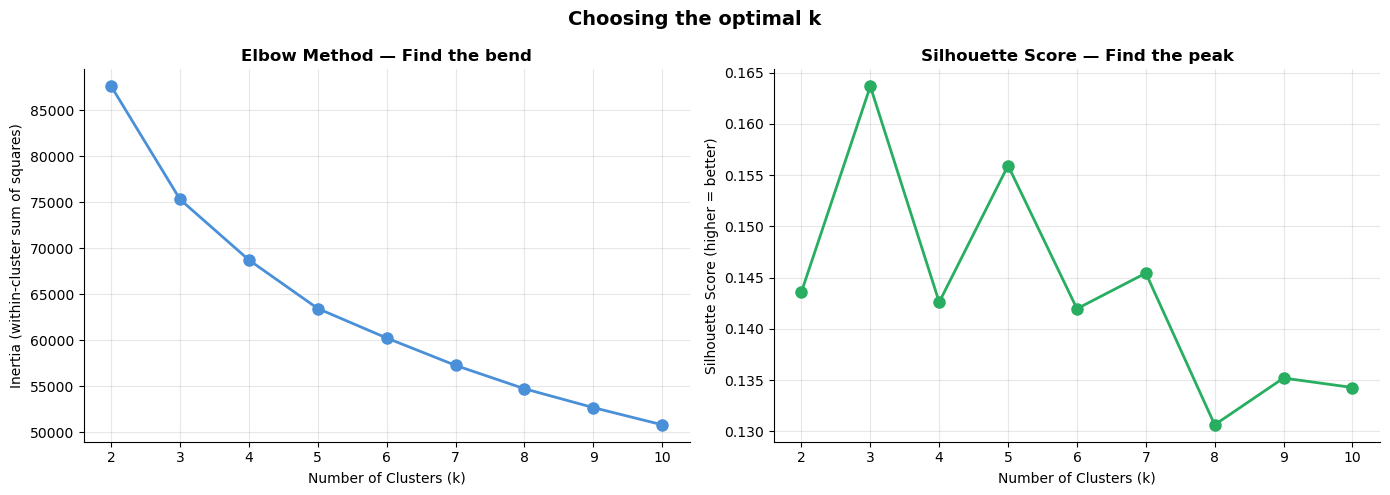

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
# Elbow curve
ax1.plot(list(K_RANGE), inertias, "o-", color="#4A90D9", linewidth=2, markersize=8)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (within-cluster sum of squares)")
ax1.set_title("Elbow Method — Find the bend", fontweight="bold")
ax1.set_xticks(list(K_RANGE))
 
# Silhouette scores
ax2.plot(list(K_RANGE), silhouettes, "o-", color="#27AE60", linewidth=2, markersize=8)
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score (higher = better)")
ax2.set_title("Silhouette Score — Find the peak", fontweight="bold")
ax2.set_xticks(list(K_RANGE))
 
plt.suptitle("Choosing the optimal k", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/05_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
best_k_silhouette = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f"\nBest k by silhouette score: {best_k_silhouette}")
print("(Compare with the elbow plot — they should roughly agree)")


Best k by silhouette score: 3
(Compare with the elbow plot — they should roughly agree)


In [25]:
OPTIMAL_K = 4  
 
km_final = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=RANDOM_STATE,
    n_init=10,       
    max_iter=300
)
 
df["Cluster"] = km_final.fit_predict(X_scaled)
 
print(f"Final K-Means model trained with k={OPTIMAL_K}")
print(f"\nCluster sizes:")
print(df["Cluster"].value_counts().sort_index())
print(f"\nSmallest cluster: {df['Cluster'].value_counts().min()} customers")
# Rule of thumb: no cluster should have fewer than ~100 customers

Final K-Means model trained with k=4

Cluster sizes:
Cluster
0    1216
1    2862
2    3602
3    2447
Name: count, dtype: int64

Smallest cluster: 1216 customers


In [26]:
# CELL 11 — Profile Each Cluster
# WHY: The cluster number (0, 1, 2, 3) has no meaning by itself.
#      We need to compute the mean of each feature per cluster
#      and compare it to the global mean to understand:
#      "What makes cluster X different from the average customer?"

In [27]:
# Mean of each feature per cluster
cluster_profile = df.groupby("Cluster")[CLUSTER_FEATURES].mean()

# Percentage deviation from global mean — this is the KEY table
global_mean = df[CLUSTER_FEATURES].mean()
deviation_pct = ((cluster_profile - global_mean) / global_mean * 100).round(1)

print("=" * 60)
print("CLUSTER PROFILES — % deviation from overall average")
print("=" * 60)
print(deviation_pct.to_string())
print("\nPositive = above average | Negative = below average")

# Also check attrition rate per cluster
attrition_map = {"Existing Customer": 0, "Attrited Customer": 1}
df["Is_Attrited"] = df_original["Attrition_Flag"].map(attrition_map)
 
attrition_by_cluster = df.groupby("Cluster")["Is_Attrited"].mean().round(3) * 100
print(f"\nAttrition rate per cluster (%):")
print(attrition_by_cluster)

CLUSTER PROFILES — % deviation from overall average
         Customer_Age  Months_on_book  Total_Relationship_Count  Months_Inactive_12_mon  Credit_Limit  Total_Revolving_Bal  Avg_Utilization_Ratio  Total_Trans_Amt  Total_Trans_Ct  Total_Ct_Chng_Q4_Q1
Cluster                                                                                                                                                                                                
0                -1.7            -1.7                     -44.4                    -5.6          80.5                 21.3                  -39.6            175.0            57.3                  1.4
1                12.5            14.4                       5.8                     0.9         -50.7                 45.1                   89.6            -20.8            -4.9                  3.8
2                 3.1             4.3                       3.3                     6.0          34.8                -59.1                  -85.3   

In [28]:
CLUSTER_NAMES = {
    0: "VIP / High Transactors",   
    1: "Revolving Debtors",
    2: "Churn-Risk / Inactive",
    3: "Young / New Clients",
}
 
df["Segment"] = df["Cluster"].map(CLUSTER_NAMES)
print("Cluster → Segment mapping applied.")
print(df["Segment"].value_counts())

Cluster → Segment mapping applied.
Segment
Churn-Risk / Inactive     3602
Revolving Debtors         2862
Young / New Clients       2447
VIP / High Transactors    1216
Name: count, dtype: int64


In [29]:
# Shorten feature names for the plot
SHORT_NAMES = {
    "Customer_Age": "Age",
    "Months_on_book": "Tenure",
    "Total_Relationship_Count": "# Products",
    "Months_Inactive_12_mon": "Months Inactive",
    "Credit_Limit": "Credit Limit",
    "Total_Revolving_Bal": "Revolving Bal.",
    "Avg_Utilization_Ratio": "Utilization %",
    "Total_Trans_Amt": "Trans. Amount",
    "Total_Trans_Ct": "Trans. Count",
    "Total_Ct_Chng_Q4_Q1": "Activity Trend"
}

heatmap_data = deviation_pct.rename(columns=SHORT_NAMES)
heatmap_data.index = [CLUSTER_NAMES.get(i, f"Cluster {i}") for i in heatmap_data.index]

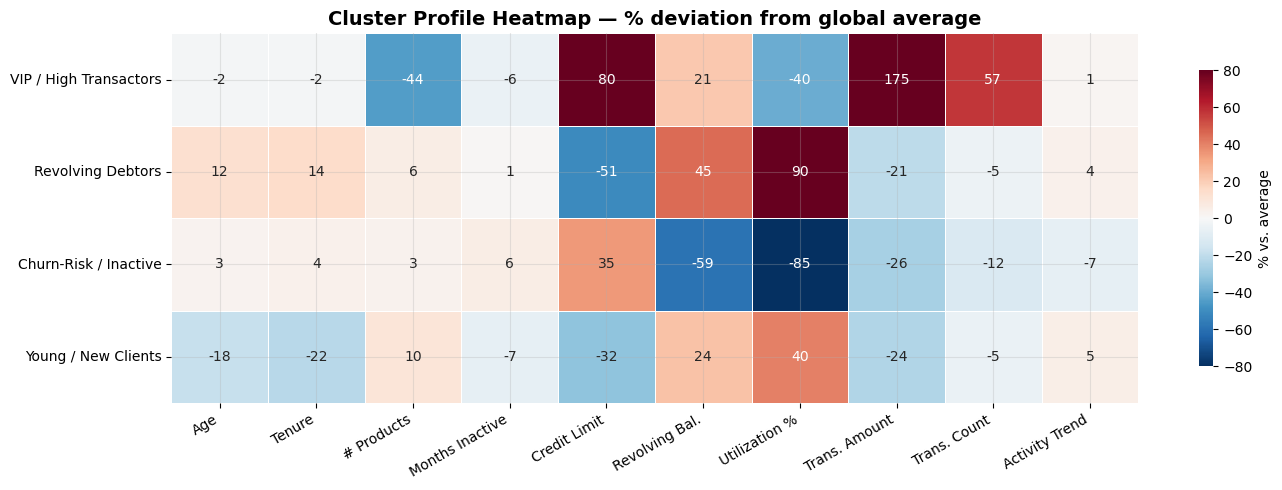

In [ ]:
plt.figure(figsize=(14, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".0f",
    cmap="RdBu_r", center=0,
    linewidths=0.5, cbar_kws={"label": "% vs. average", "shrink": 0.8},
    vmin=-80, vmax=80
)
plt.title("Cluster Profile Heatmap — % deviation from global average", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../plots/06_cluster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Running UMAP (may take 30–60 seconds)...


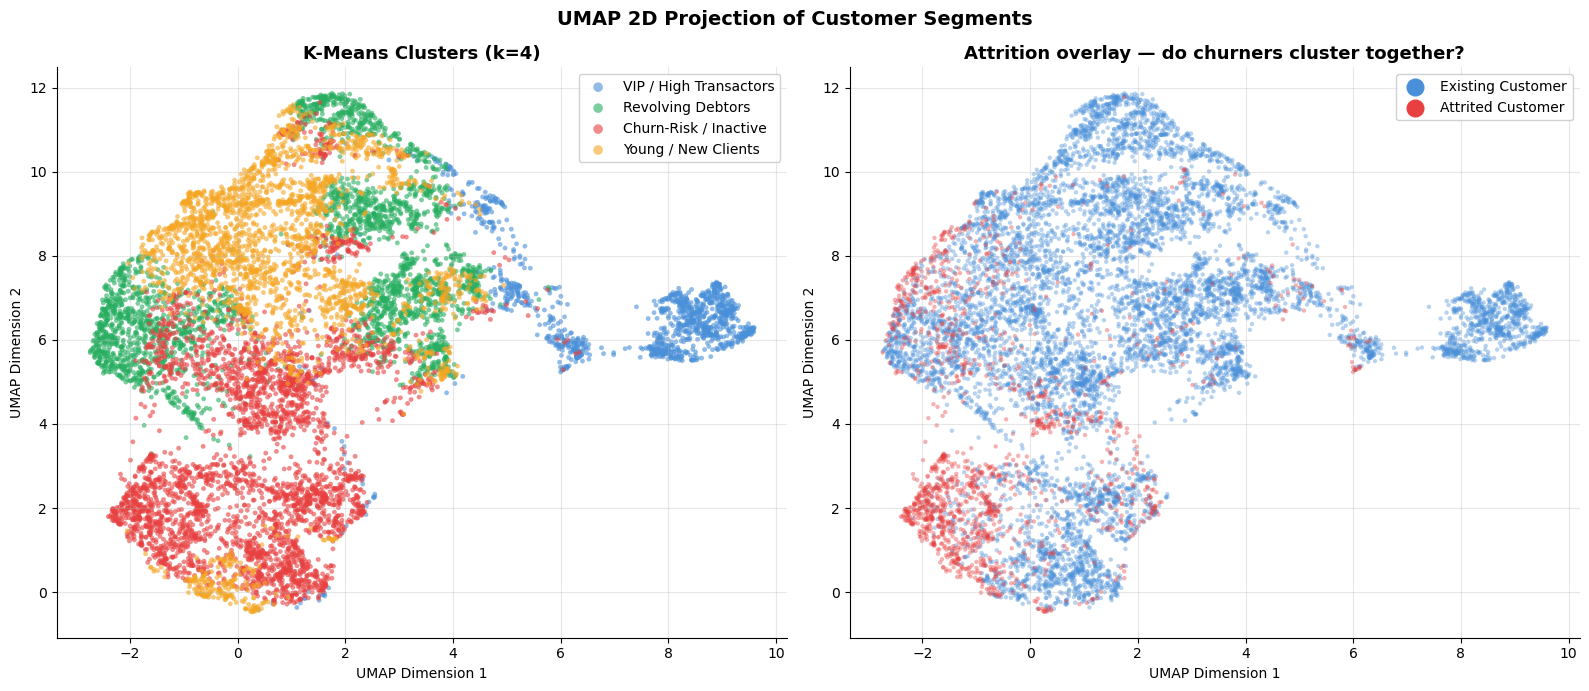

In [ ]:
print("Running UMAP (may take 30–60 seconds)...")
 
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    random_state=RANDOM_STATE
)
X_2d = reducer.fit_transform(X_pca)  
 
df["UMAP_1"] = X_2d[:, 0]
df["UMAP_2"] = X_2d[:, 1]
 
COLORS = ["#4A90D9", "#27AE60", "#E84040", "#F5A623"]
 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
 
# Left: by cluster number
for cluster_id in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == cluster_id
    axes[0].scatter(
        df.loc[mask, "UMAP_1"],
        df.loc[mask, "UMAP_2"],
        c=COLORS[cluster_id], label=CLUSTER_NAMES.get(cluster_id, f"Cluster {cluster_id}"),
        alpha=0.6, s=12, edgecolors="none"
    )
axes[0].set_title("K-Means Clusters (k=4)", fontweight="bold", fontsize=13)
axes[0].legend(markerscale=2, framealpha=0.9)
axes[0].set_xlabel("UMAP Dimension 1")
axes[0].set_ylabel("UMAP Dimension 2")
 
# Right: by attrition status
churn_colors = df["Is_Attrited"].map({0: "#4A90D9", 1: "#E84040"})
axes[1].scatter(df["UMAP_1"], df["UMAP_2"], c=churn_colors, alpha=0.4, s=10, edgecolors="none")
axes[1].scatter([], [], c="#4A90D9", label="Existing Customer")
axes[1].scatter([], [], c="#E84040", label="Attrited Customer")
axes[1].set_title("Attrition overlay — do churners cluster together?", fontweight="bold", fontsize=13)
axes[1].legend(markerscale=2, framealpha=0.9)
axes[1].set_xlabel("UMAP Dimension 1")
axes[1].set_ylabel("UMAP Dimension 2")
 
plt.suptitle("UMAP 2D Projection of Customer Segments", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/07_umap.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
from sklearn.preprocessing import MinMaxScaler
 
radar_data = cluster_profile.copy()
mms = MinMaxScaler()
radar_normalized = pd.DataFrame(
    mms.fit_transform(radar_data),
    columns=radar_data.columns,
    index=radar_data.index
).rename(columns=SHORT_NAMES)
 
FEATURES_RADAR = list(radar_normalized.columns)
N = len(FEATURES_RADAR)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  

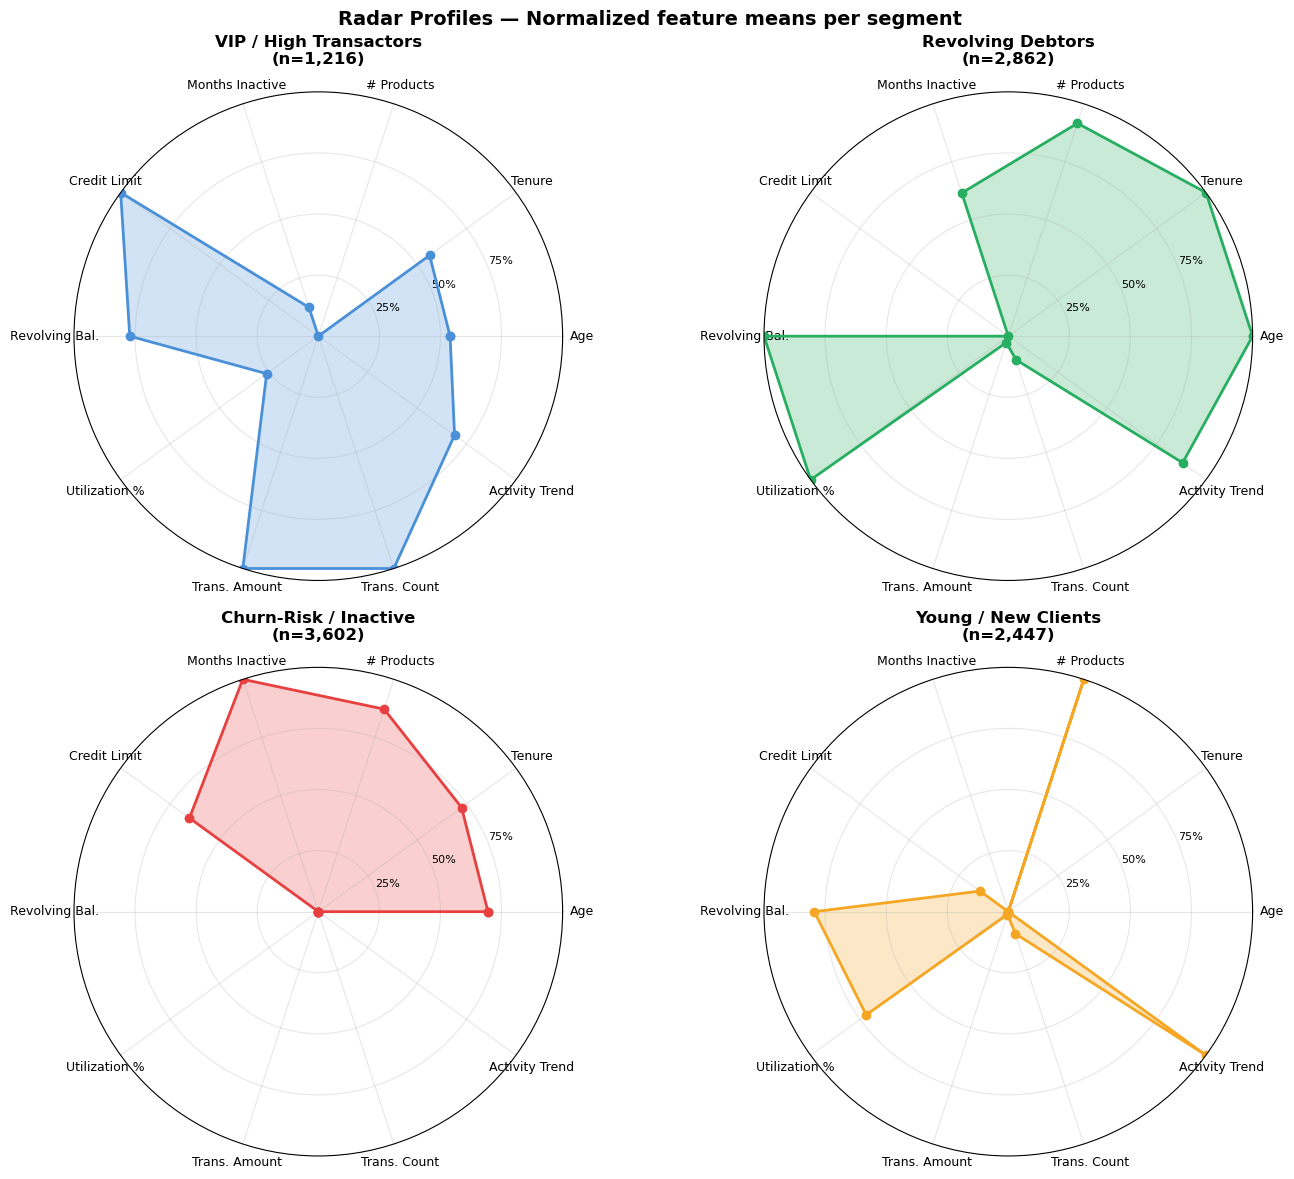

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw={"polar": True})
axes = axes.flatten()
 
for idx, (cluster_id, row) in enumerate(radar_normalized.iterrows()):
    values = row.tolist() + row.tolist()[:1]  # close the polygon
    ax = axes[idx]
    ax.plot(angles, values, "o-", linewidth=2, color=COLORS[cluster_id])
    ax.fill(angles, values, alpha=0.25, color=COLORS[cluster_id])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(FEATURES_RADAR, size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["25%", "50%", "75%"], size=8)
    segment_name = CLUSTER_NAMES.get(cluster_id, f"Cluster {cluster_id}")
    size = df[df["Cluster"] == cluster_id].shape[0]
    ax.set_title(f"{segment_name}\n(n={size:,})", fontweight="bold", pad=20)
 
plt.suptitle("Radar Profiles — Normalized feature means per segment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/08_radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
from sklearn.neighbors import NearestNeighbors
 
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
kth_distances = np.sort(distances[:, 4])[::-1]  


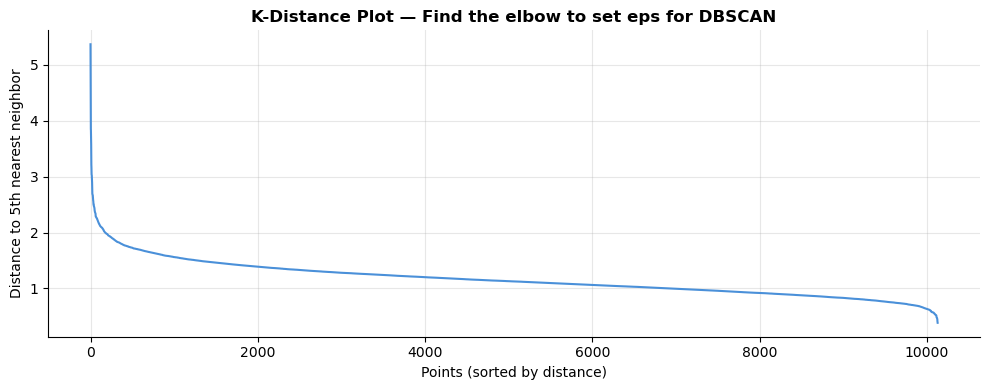

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(kth_distances, color="#4A90D9", linewidth=1.5)
plt.xlabel("Points (sorted by distance)")
plt.ylabel("Distance to 5th nearest neighbor")
plt.title("K-Distance Plot — Find the elbow to set eps for DBSCAN", fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/09_kdistance.png", dpi=150, bbox_inches="tight")
plt.show()

In [36]:
db = DBSCAN(eps=2.0, min_samples=50)
db_labels = db.fit_predict(X_scaled)
 
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_outliers_db = (db_labels == -1).sum()
 
print(f"DBSCAN results:")
print(f"  Clusters found: {n_clusters_db}")
print(f"  Outliers (noise points): {n_outliers_db} ({n_outliers_db/len(db_labels)*100:.1f}%)")
print(f"\nCluster size distribution:")
print(pd.Series(db_labels).value_counts())

DBSCAN results:
  Clusters found: 1
  Outliers (noise points): 315 (3.1%)

Cluster size distribution:
 0    9812
-1     315
Name: count, dtype: int64


In [37]:
sil = silhouette_score(X_scaled, df["Cluster"], sample_size=5000, random_state=RANDOM_STATE)
db_score = davies_bouldin_score(X_scaled, df["Cluster"])
 
print("=" * 50)
print("CLUSTERING EVALUATION METRICS")
print("=" * 50)
print(f"Silhouette Score:     {sil:.4f}")
print(f"  → Range: -1 to 1   | Good: above 0.4 | Great: above 0.6")
print(f"\nDavies-Bouldin Score: {db_score:.4f}")
print(f"  → Range: 0 to ∞    | Lower is better | Good: below 1.0")
print(f"\nCluster sizes (for business feasibility check):")
print(df["Cluster"].value_counts().sort_index().to_string())
print("\nAttrition rate per segment:")
print(df.groupby("Segment")["Is_Attrited"].mean().mul(100).round(1).to_string())
 

CLUSTERING EVALUATION METRICS
Silhouette Score:     0.1451
  → Range: -1 to 1   | Good: above 0.4 | Great: above 0.6

Davies-Bouldin Score: 1.8025
  → Range: 0 to ∞    | Lower is better | Good: below 1.0

Cluster sizes (for business feasibility check):
Cluster
0    1216
1    2862
2    3602
3    2447

Attrition rate per segment:
Segment
Churn-Risk / Inactive     30.0
Revolving Debtors          9.0
VIP / High Transactors     5.0
Young / New Clients        9.3


In [38]:
RECOMMENDATIONS = {
    "VIP High Transactors": {
        "profile": "Highest Transaction Amount (+175%) and Volume, High Credit Limit, Lowest Churn (5%)",
        "risk": "Very Low — These are your most profitable and loyal clients",
        "action": [
            "Offer Platinum/Infinite card upgrades with higher limits",
            "Provide exclusive access to airport lounges and concierge services",
            "Assign a dedicated relationship manager for personalized service",
            "Enroll in a high-tier points multiplier program for every transaction"
        ]
    },
    "Revolving Debtors": {
        "profile": "Highest Utilization Ratio (+89.6%) and Revolving Balance, Moderate Churn (9%)",
        "risk": "Medium — Profitable due to interest, but vulnerable to financial stress",
        "action": [
            "Promote 'Installment Plans' for large purchases to manage debt",
            "Offer balance transfer promotions with lower interest for a limited time",
            "Cross-sell insurance products (Life/Job loss) as they carry high balances",
            "Monitor for sudden drops in 'Change in Transaction Count' (Q4 vs Q1)"
        ]
    },
    "Inactive Churn-Risk": {
        "profile": "Highest Churn Rate (30%), Lowest Transaction Amount (-85%), High Inactivity",
        "risk": "Critical — 1 in 3 customers in this group will leave",
        "action": [
            "Immediate 'Re-activation' campaign with high-value cashback or vouchers",
            "Direct phone outreach to understand why they stopped using the card",
            "Offer to waive annual fees in exchange for a minimum spend over 3 months",
            "Simplify the UI/UX if they find the digital services difficult to use"
        ]
    },
    "Young New Clients": {
        "profile": "Lowest Age and Tenure, but High Number of Products (+10.4%)",
        "risk": "Low to Medium — Still exploring the bank's services",
        "action": [
            "Promote educational content on personal finance and credit building",
            "Offer 'Student' or 'First-Job' specialized credit products",
            "Focus on Mobile App engagement and digital wallet integrations (Apple/Google Pay)",
            "Encourage salary transfer to the bank with 'New Joiner' bonuses"
        ]
    }
}

print("=" * 80)
print("STRATEGIC BUSINESS RECOMMENDATIONS (Based on Cluster Deviations)")
print("=" * 80)

for segment, details in RECOMMENDATIONS.items():
    print(f"\n{'─' * 75}")
    print(f"  TARGET SEGMENT: {segment.upper()}")
    print(f"  DATA PROFILE:   {details['profile']}")
    print(f"  RISK LEVEL:     {details['risk']}")
    print(f"  STRATEGIC ACTIONS:")
    for action in details["action"]:
        print(f"    • {action}")

STRATEGIC BUSINESS RECOMMENDATIONS (Based on Cluster Deviations)

───────────────────────────────────────────────────────────────────────────
  TARGET SEGMENT: VIP HIGH TRANSACTORS
  DATA PROFILE:   Highest Transaction Amount (+175%) and Volume, High Credit Limit, Lowest Churn (5%)
  RISK LEVEL:     Very Low — These are your most profitable and loyal clients
  STRATEGIC ACTIONS:
    • Offer Platinum/Infinite card upgrades with higher limits
    • Provide exclusive access to airport lounges and concierge services
    • Assign a dedicated relationship manager for personalized service
    • Enroll in a high-tier points multiplier program for every transaction

───────────────────────────────────────────────────────────────────────────
  TARGET SEGMENT: REVOLVING DEBTORS
  DATA PROFILE:   Highest Utilization Ratio (+89.6%) and Revolving Balance, Moderate Churn (9%)
  RISK LEVEL:     Medium — Profitable due to interest, but vulnerable to financial stress
  STRATEGIC ACTIONS:
    • Promote '

In [ ]:
# Save the full dataframe with cluster assignments
output_cols = ["CLIENTNUM", "Attrition_Flag", "Cluster", "Segment"] + CLUSTER_FEATURES
df_export = df_original.merge(
    df[["CLIENTNUM", "Cluster", "Segment"]],
    on="CLIENTNUM", how="left"
)
df_export.to_csv("../outputs/customer_segments_output.csv", index=False)
print(f"Saved: customer_segments_output.csv ({df_export.shape[0]:,} rows)")
 
# Save cluster profile summary
cluster_profile.to_csv("../outputs/cluster_profile_means.csv")
deviation_pct.to_csv("../outputs/cluster_profile_deviation.csv")
print("Saved: cluster_profile_means.csv & cluster_profile_deviation.csv")
 

Saved: customer_segments_output.csv (10,127 rows)
Saved: cluster_profile_means.csv & cluster_profile_deviation.csv
